# Task 2 Deliberation: Cross-Validation, Learning Curves, and Fairness Analysis

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, make_scorer
import matplotlib.pyplot as plt

df = pd.read_csv('https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv')
df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'])
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
df_encoded = df.copy()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

## 1. Stratified 5-Fold Cross-Validation

In [2]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
f1_scorer = make_scorer(f1_score)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
dtree = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)

cv_scores_lr = cross_val_score(logreg, X_scaled, y, cv=skf, scoring=f1_scorer)
cv_scores_dt = cross_val_score(dtree, X, y, cv=skf, scoring=f1_scorer)

print("Logistic Regression mean F1:", round(cv_scores_lr.mean(), 3), "+/-", round(cv_scores_lr.std(), 3))
print("Decision Tree mean F1:", round(cv_scores_dt.mean(), 3), "+/-", round(cv_scores_dt.std(), 3))

Logistic Regression mean F1: 0.469 +/- 0.017
Decision Tree mean F1: 0.435 +/- 0.027


## 2. Learning Curves

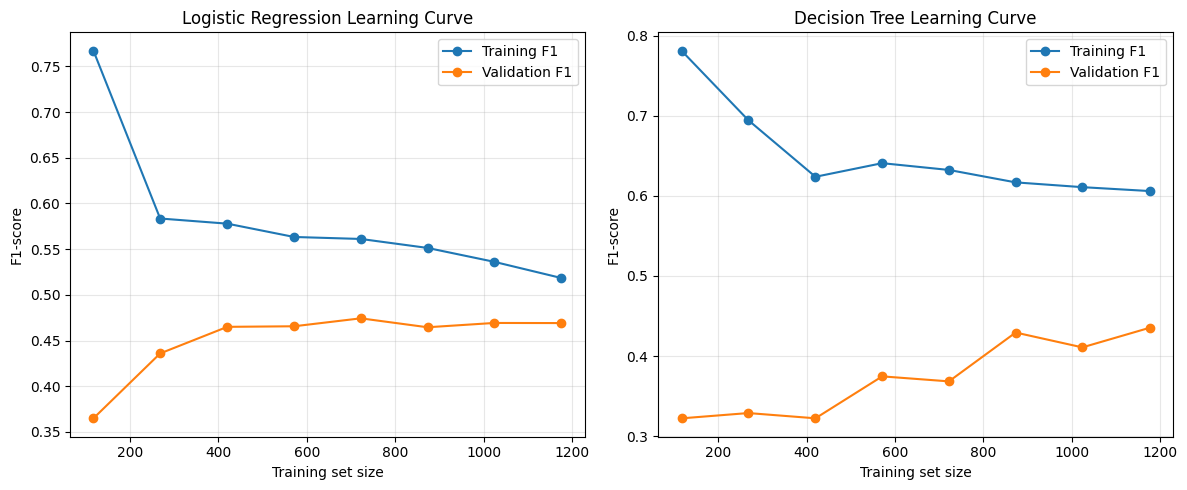

In [3]:
train_sizes = np.linspace(0.1, 1.0, 8)

train_sizes_lr, train_scores_lr, val_scores_lr = learning_curve(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    X_scaled, y, cv=skf, train_sizes=train_sizes, scoring=f1_scorer, random_state=42
)
train_sizes_dt, train_scores_dt, val_scores_dt = learning_curve(
    DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    X, y, cv=skf, train_sizes=train_sizes, scoring=f1_scorer, random_state=42
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(train_sizes_lr, train_scores_lr.mean(axis=1), 'o-', label='Training F1')
axes[0].plot(train_sizes_lr, val_scores_lr.mean(axis=1), 'o-', label='Validation F1')
axes[0].set_title('Logistic Regression Learning Curve')
axes[0].set_xlabel('Training set size')
axes[0].set_ylabel('F1-score')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(train_sizes_dt, train_scores_dt.mean(axis=1), 'o-', label='Training F1')
axes[1].plot(train_sizes_dt, val_scores_dt.mean(axis=1), 'o-', label='Validation F1')
axes[1].set_title('Decision Tree Learning Curve')
axes[1].set_xlabel('Training set size')
axes[1].set_ylabel('F1-score')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Fairness Analysis (Fairlearn)

In [4]:
from fairlearn.metrics import MetricFrame, selection_rate, demographic_parity_difference, equalized_odds_difference

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg_final = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg_final.fit(X_train_scaled, y_train)
pred = logreg_final.predict(X_test_scaled)

gender_test = df.loc[X_test.index, 'Gender']
mf = MetricFrame(
    metrics={'selection_rate': selection_rate, 'recall': recall_score, 'accuracy': accuracy_score},
    y_true=y_test, y_pred=pred, sensitive_features=gender_test
)
print("Fairness by Gender:")
print(mf.by_group)
print("Demographic parity difference:", round(demographic_parity_difference(y_test, pred, sensitive_features=gender_test), 3))
print("Equalized odds difference:", round(equalized_odds_difference(y_test, pred, sensitive_features=gender_test), 3))

age_test = df.loc[X_test.index, 'Age']
age_group = pd.cut(age_test, bins=[17, 30, 45, 61], labels=['18-30', '31-45', '46-60'])
mf_age = MetricFrame(
    metrics={'selection_rate': selection_rate, 'recall': recall_score, 'accuracy': accuracy_score},
    y_true=y_test, y_pred=pred, sensitive_features=age_group
)
print("\nFairness by Age group:")
print(mf_age.by_group)
print("Demographic parity difference (age):", round(demographic_parity_difference(y_test, pred, sensitive_features=age_group), 3))
print("Equalized odds difference (age):", round(equalized_odds_difference(y_test, pred, sensitive_features=age_group), 3))

Fairness by Gender:
        selection_rate    recall  accuracy
Gender                                    
Female        0.309353  0.650000  0.733813
Male          0.288210  0.692308  0.777293
Demographic parity difference: 0.021
Equalized odds difference: 0.047

Fairness by Age group:
       selection_rate  recall  accuracy
Age                                    
18-30        0.457447    0.75  0.670213
31-45        0.288462    0.72  0.764423
46-60        0.090909    0.40  0.878788
Demographic parity difference (age): 0.367
Equalized odds difference (age): 0.35
